# 02_Core_Concepts.ipynb — Polynomial Regression

---

# Working Intuition

The main idea behind Polynomial Regression is:

> **Instead of changing the algorithm, we change the input features.**

Linear Regression can only learn a relationship of the form:

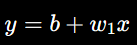

which is a straight line.

Polynomial Regression first **expands the features** and then applies ordinary Linear Regression.

---

## Step 1: Original Feature

Suppose our dataset has one feature:

| x |
| - |
| 1 |
| 2 |
| 3 |
| 4 |

The model sees only:

```text
x
```

A straight line is the best it can learn.

---

## Step 2: Expand Features

Suppose degree = 2.

Instead of using only x, we create

| x | x² |
| - | -- |
| 1 | 1  |
| 2 | 4  |
| 3 | 9  |
| 4 | 16 |

Now the model receives

```text
x
x²
```

instead of just

```text
x
```

---

## Step 3: Train Linear Regression

Now Linear Regression learns

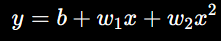

Notice that the algorithm is **still Linear Regression**.

Only the inputs changed.

---

## Why Does This Create Curves?

Suppose

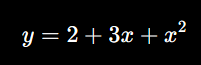

When x increases,

* x increases normally
* x² increases much faster

The combined effect bends the prediction into a curve.

Example

| x | x² | Prediction |
| - | -- | ---------- |
| 1 | 1  | 6          |
| 2 | 4  | 12         |
| 3 | 9  | 20         |
| 4 | 16 | 30         |

The outputs no longer increase by a constant amount.

Hence, the graph becomes curved.

---

## Increasing the Degree

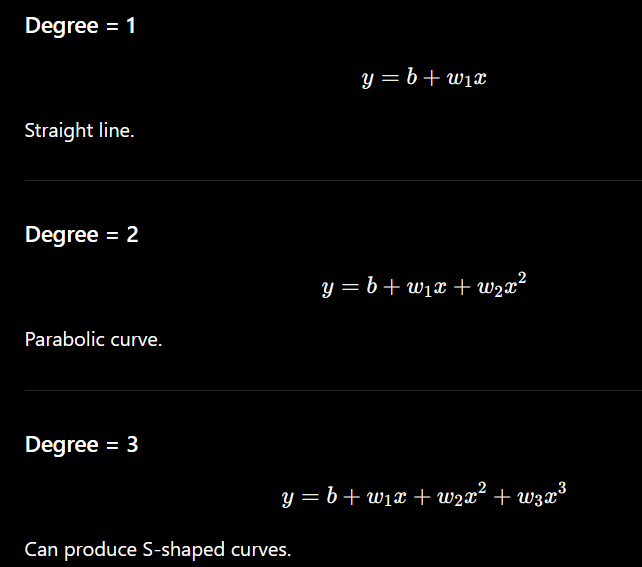

---

### Degree = 4

Even more flexible.

---

### Degree = 10

Can fit highly complex curves.

But this increases the risk of **overfitting**.

---

## Intuition with Graphs

### Degree = 1

```text
•
 \
  \
   \
    \
```

---

### Degree = 2

```text
      •
    •
  •
•
 \
  \
```

---

### Degree = 3

```text
•
 \
  \
   •
     \
      •
```

---

Higher degree means **higher flexibility**, but also **higher variance**.

---

# Important Terminology

---

## 1. Polynomial

A polynomial is an expression made of variables raised to non-negative integer powers.

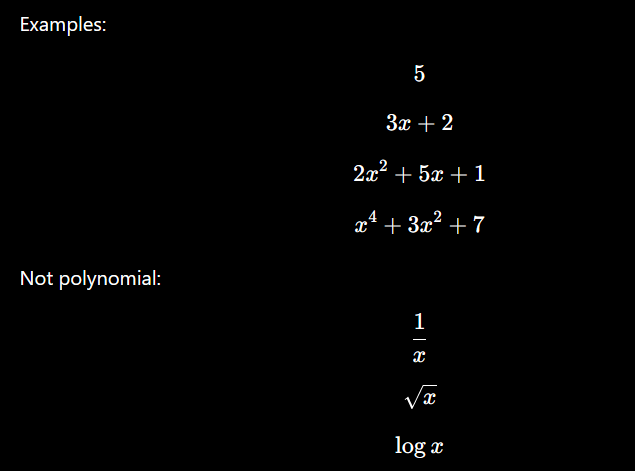

---

## 2. Degree

The highest power of x.

Examples

| Equation | Degree |
| -------- | ------ |
| x+1      | 1      |
| x²+2     | 2      |
| x³+5     | 3      |
| x⁵+x²    | 5      |

Degree controls model complexity.

Higher degree

↓

More flexibility

↓

Higher chance of overfitting.

---

## 3. Polynomial Features

Extra features generated automatically.

Original:

```text
x
```

Degree = 3

Generated:

```text
x
x²
x³
```

For multiple features:

Original

```text
x1
x2
```

Degree = 2

Generated

```text
x1
x2
x1²
x2²
x1*x2
```

Notice the interaction term:

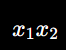

---

## 4. Interaction Features

Products of different features.

Example

Original

```text
Height
Weight
```

Interaction

```text
Height × Weight
```

This helps model relationships where one feature influences another.

---

## 5. Underfitting

Model too simple.

Example

Trying to fit

```text
)
 )
 )
 )
```

using

```text
/
```

High bias.

Poor train accuracy.

Poor test accuracy.

---

## 6. Overfitting

Model too complex.

Example

```text
•~~~~~~•~~~~~~•
```

Instead of a smooth curve.

Low training error.

High testing error.

---

## 7. Bias-Variance Tradeoff

As degree increases

Bias ↓

Variance ↑

Example

```text
Degree 1
High Bias
Low Variance

↓

Degree 3
Balanced

↓

Degree 20
Low Bias
High Variance
```

Choosing the degree is about balancing these two.

---

# Assumptions

Polynomial Regression shares most assumptions with Linear Regression, but with transformed features.

---

## 1. Relationship is Polynomial

The true relationship should be reasonably approximated by a polynomial.

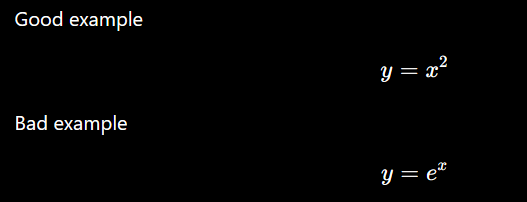
---

## 2. Independent Observations

Each sample should be independent of the others.

Example

Student exam scores

✓ Independent

Stock prices over time

✗ Consecutive values are dependent (time series).

---

## 3. Errors Have Mean Zero

Residuals should average approximately zero.

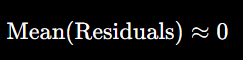
---

## 4. Constant Error Variance (Homoscedasticity)

Residual spread should stay roughly constant across predictions.

Good

```text
*****
*****
*****
```

Bad (heteroscedasticity)

```text
*
**
****
*******
***********
```

---

## 5. No Extreme Multicollinearity

Polynomial features are naturally correlated.

Example

```text
x

x²

x³
```

are highly correlated.

This is why Ridge Regression is commonly combined with Polynomial Features.

---

## 6. Outliers Should Be Limited

Because squared error is used,

large outliers can significantly influence the fitted curve.

---

# Types / Variants

Polynomial Regression itself has no different algorithms, but it can vary based on the degree and feature construction.

---

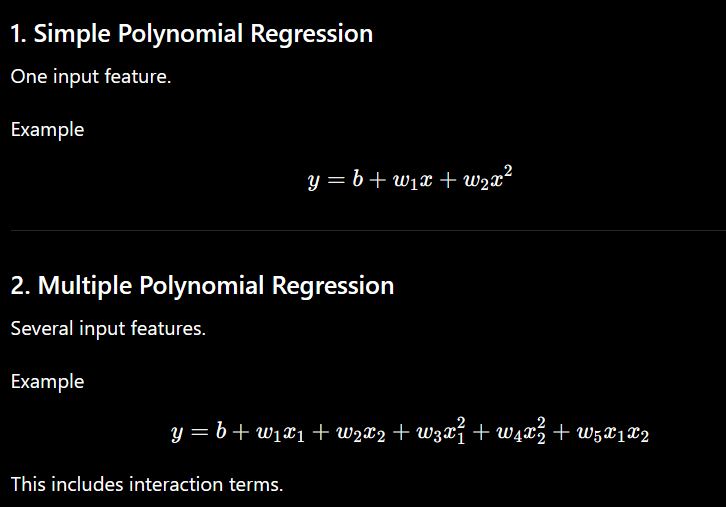

---

## 3. Polynomial Regression with Regularization

Polynomial Features

↓

Ridge

or

Lasso

or

Elastic Net

Used to reduce overfitting.

This is the most common practical approach.

---

# Decision Boundary / Model Behavior

Polynomial Regression is a **regression algorithm**, so it does **not** have a decision boundary like Logistic Regression or SVM.

Instead, it learns a **prediction curve (or surface in higher dimensions)**.

### Degree = 1

```text
\
 \
  \
```

---

### Degree = 2

```text
 )
)
```

---

### Degree = 5

```text
~~~
```

---

As the degree increases:

* The curve becomes more flexible.
* It can fit more complex relationships.
* It also becomes more sensitive to noise.

For multiple features, instead of a curve, the model learns a **curved surface**.

---

# Advantages & Disadvantages

## Advantages

### 1. Models Non-linear Relationships

Can fit curved data while still using Linear Regression.

---

### 2. Simple Extension of Linear Regression

No new optimization algorithm is required.

---

### 3. Easy to Implement

In scikit-learn:

```python
PolynomialFeatures()
LinearRegression()
```

---

### 4. Fast for Low Degrees

Training remains efficient when the number of generated features is manageable.

---

### 5. Interpretable

The contribution of each polynomial term can be examined through its coefficient.

---

## Disadvantages

### 1. Overfitting

High-degree polynomials may fit noise instead of the true pattern.

---

### 2. Multicollinearity

Terms like x, x², and x³ are strongly correlated, leading to unstable coefficients.

---

### 3. Feature Explosion

The number of generated features grows rapidly with:

* More original features
* Higher polynomial degree

This increases memory and computation requirements.

---

### 4. Poor Extrapolation

Predictions outside the training range can become unrealistic.

---

### 5. Sensitive to Outliers

Like Linear Regression, it minimizes squared error, making it vulnerable to extreme values.

---

# When To Use / Avoid

## Use Polynomial Regression When

### ✔ The relationship is non-linear but smooth.

---

### ✔ You have relatively few input features.

Polynomial feature expansion is manageable.

---

### ✔ The dataset is small to medium-sized.

---

### ✔ The polynomial degree needed is relatively low (typically 2–4).

---

### ✔ You want a model that remains interpretable.

---

## Avoid Polynomial Regression When

### ✘ The relationship is highly irregular or discontinuous.

Methods like Decision Trees or Random Forests may perform better.

---

### ✘ You have many input features.

The number of polynomial features grows combinatorially.

---

### ✘ You need predictions far beyond the training data.

Polynomial models extrapolate poorly.

---

### ✘ The data contains many outliers.

The fitted curve can become distorted.

---

### ✘ A very high degree is required.

A high-degree polynomial often overfits and generalizes poorly. In such cases, other non-linear models (e.g., tree-based models, kernel methods, or neural networks) are often more appropriate.

---
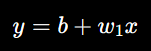

# **Important**

**`But how do we see whcih featur we shoudl square and add as feature or know that the data is non linear so we should use poolynomial regression
The short answer is:`**

> **You usually don't manually decide "square this feature but not that one."** Instead, you first determine whether a **non-linear relationship exists**, then generate polynomial features (for selected numerical features), and finally let validation determine whether they improve the model.

Let's go through how this is done in practice.

---

# Step 1: Check Whether the Relationship Looks Linear

The first thing to do is visualize each feature against the target.

```python
import matplotlib.pyplot as plt

plt.scatter(df["Age"], df["Salary"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()
```

### Case 1: Linear

```text
y
|
|         •
|      •
|    •
|  •
|•
+---------------- x
```

A straight line fits well.

➡️ Linear Regression is sufficient.

---

### Case 2: Curved

```text
y
|
|           •
|       •
|    •
|  •
|•
|    •
|        •
+---------------- x
```

A straight line clearly won't fit.

➡️ Polynomial Regression becomes a good candidate.

---

# Step 2: Fit a Linear Regression First

You almost never start directly with Polynomial Regression.

Typical workflow:

```text
Linear Regression
      ↓
Evaluate
      ↓
If underfitting
      ↓
Try Polynomial Regression
```

Suppose your results are:

```text
Train R² = 0.42
Test R² = 0.39
```

Both are poor.

This indicates **underfitting**.

Now try Polynomial Regression.

---

# Step 3: Look at the Residual Plot

This is one of the best indicators.

Residual =

```text
Actual − Prediction
```

Good residual plot

```text
Residual

  *
 * *
*****
 * *
  *

-------------------- Prediction
```

Random scatter around zero.

Linear model is appropriate.

---

Bad residual plot

```text
Residual

     ***
   **
 **
*
 **
   ***
```

Residuals form a pattern.

This means:

> The model is missing some structure.

Often this structure is non-linear.

---

# Step 4: Compare Validation Scores

Instead of guessing, compare models.

```python
Degree 1 → R² = 0.71
Degree 2 → R² = 0.89
Degree 3 → R² = 0.91
Degree 4 → R² = 0.90
Degree 5 → R² = 0.82
```

Clearly,

Degree 3 is best.

This is why we use **cross-validation** instead of intuition.

---

# Which Features Should Be Squared?

This is the part many beginners misunderstand.

Suppose your dataset is

| Age | Income | Experience | Salary |
| --- | ------ | ---------- | ------ |

Do we manually choose

```text
Age²
Income²

NOT Experience²
```

?

Usually **No**.

Instead,

```python
PolynomialFeatures(degree=2)
```

automatically generates

```text
Age
Income
Experience

Age²
Income²
Experience²

Age × Income
Age × Experience
Income × Experience
```

Everything is generated.

---

# Then Isn't That Too Many Features?

Exactly.

That's why we evaluate.

Some of these new features will help.

Some won't.

Sometimes we combine Polynomial Features with **Ridge** or **Lasso** so unhelpful terms get shrunk (or, with Lasso, some can even become zero).

---

# What If I Know One Feature Is Already Linear?

Then you can manually choose.

Suppose

```text
Age → curved

Experience → linear
```

You can create only

```python
df["Age²"] = df["Age"] ** 2
```

and leave Experience unchanged.

This is called **manual feature engineering**.

Experts often do this when they have domain knowledge.

---

# Example

House Prices

| Feature            | Relationship  |
| ------------------ | ------------- |
| House Age          | Curved        |
| Distance to City   | Curved        |
| Number of Bedrooms | Mostly Linear |

You might create

```text
HouseAge²

Distance²
```

but not

```text
Bedrooms²
```

because squaring the number of bedrooms may not add useful information.

---

# How Do Data Scientists Decide?

A common workflow is:

```text
1. Understand the problem
          ↓
2. Plot each feature vs target
          ↓
3. Train Linear Regression
          ↓
4. Check residual plots
          ↓
5. Evaluate R² / MAE / RMSE
          ↓
6. If underfitting → Try Polynomial Features
          ↓
7. Use Cross Validation
          ↓
8. Keep the degree that generalizes best
```

This is far more reliable than guessing.

---

# In Industry

Data scientists rarely think:

> "Let's square feature 3."

Instead, they think:

* Does the linear model underfit?
* Do plots suggest curvature?
* Does adding polynomial features improve validation performance?
* Does the improvement justify the added complexity?

The final decision is based on **validation metrics**, not intuition alone.

This is also why, in scikit-learn, you'll often see pipelines like:

```python
Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])
```

The polynomial features are generated automatically, and cross-validation is then used to determine whether this approach performs better than a simpler linear model.
